MASK crs: EPSG:4326 dtype: ('uint8',) count: 1 nodata: None
MASK shape: (39678, 42334) transform: | 0.00, 0.00,-61.63|
| 0.00,-0.00,-7.35|
| 0.00, 0.00, 1.00|
MASK sample unique: {0: 4194304}


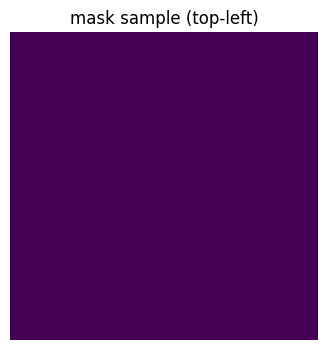

In [1]:
# CÉLULA 1 — paths + sanity check da máscara C10 (1/255)
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

MASK_PATH   = Path("/content/drive/MyDrive/GEE_Exports/c10_agri_mt_2023_1_255.tif")
UNET_FULL   = Path("/content/drive/MyDrive/unet_preds_mt2023_v1/unet_mt2023_pred_full.tif")
RF_MAP      = Path("/content/drive/MyDrive/GEE_Exports/rf_milho_mask1_mt_2023_c10.tif")

OUT_DIR     = Path("/content/drive/MyDrive/unet_preds_mt2023_v1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert MASK_PATH.exists(), f"não achei MASK_PATH: {MASK_PATH}"
assert UNET_FULL.exists(), f"não achei UNET_FULL: {UNET_FULL}"
assert RF_MAP.exists(), f"não achei RF_MAP: {RF_MAP}"

with rasterio.open(MASK_PATH) as ds:
    print("MASK crs:", ds.crs, "dtype:", ds.dtypes, "count:", ds.count, "nodata:", ds.nodata)
    print("MASK shape:", (ds.height, ds.width), "transform:", ds.transform)
    # amostra pequena p/ unique
    w = min(2048, ds.width); h = min(2048, ds.height)
    arr = ds.read(1, window=rasterio.windows.Window(0, 0, w, h))
    u, c = np.unique(arr, return_counts=True)
    print("MASK sample unique:", dict(zip(u.tolist(), c.tolist())))

    plt.figure(figsize=(6,4))
    plt.imshow(arr, vmin=0, vmax=255)
    plt.title("mask sample (top-left)")
    plt.axis("off")
    plt.show()

In [2]:
# CÉLULA 2 — checar alinhamento básico (mask vs unet_full)
import rasterio

with rasterio.open(UNET_FULL) as u, rasterio.open(MASK_PATH) as m:
    print("UNET crs:", u.crs, "shape:", (u.height,u.width), "transform:", u.transform)
    print("MASK crs:", m.crs, "shape:", (m.height,m.width), "transform:", m.transform)
    print("UNET bounds:", u.bounds)
    print("MASK bounds:", m.bounds)

    # se crs diferir, ainda funciona (reproject), mas aqui esperamos EPSG:4326 em ambos
    assert u.crs == m.crs, f"CRS difere: UNET={u.crs} MASK={m.crs}"

UNET crs: EPSG:4326 shape: (48240, 48240) transform: | 0.00, 0.00,-62.00|
| 0.00,-0.00,-6.00|
| 0.00, 0.00, 1.00|
MASK crs: EPSG:4326 shape: (39678, 42334) transform: | 0.00, 0.00,-61.63|
| 0.00,-0.00,-7.35|
| 0.00, 0.00, 1.00|
UNET bounds: BoundingBox(left=-62.00019377394638, bottom=-19.00017674288359, right=-48.99977498216866, top=-5.999757951105873)
MASK bounds: BoundingBox(left=-61.633411643440375, bottom=-18.041853997784884, right=-50.224627872065625, top=-7.34884784479657)


In [3]:
# CÉLULA 3 — helpers: reproject por janela (nearest) + contador de blocos
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

def _window_bounds(ds, win):
    # bounds da janela no CRS do ds
    t = ds.window_transform(win)
    left, top = (t * (0, 0))
    right, bottom = (t * (win.width, win.height))
    xmin, xmax = (left, right) if left < right else (right, left)
    ymin, ymax = (bottom, top) if bottom < top else (top, bottom)
    return xmin, ymin, xmax, ymax

def reproject_window_to_dst(src_ds, dst_win, dst_ds, band=1, src_nodata=None, dst_fill=255, dtype=np.uint8):
    """
    Reamostra um pedaço do src_ds para a grade do dst_ds na janela dst_win.
    Retorna array (dst_win.height, dst_win.width).
    """
    dst = np.full((dst_win.height, dst_win.width), dst_fill, dtype=dtype)

    xmin, ymin, xmax, ymax = _window_bounds(dst_ds, dst_win)

    # janela correspondente no src (mesmo CRS; se fosse diferente, ainda assim ok com reproject)
    try:
        src_win = src_ds.window(xmin, ymin, xmax, ymax)
    except Exception:
        return dst

    src_arr = src_ds.read(band, window=src_win, boundless=True,
                          fill_value=(src_nodata if src_nodata is not None else 0))
    src_t = src_ds.window_transform(src_win)

    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_t,
        src_crs=src_ds.crs,
        dst_transform=dst_ds.window_transform(dst_win),
        dst_crs=dst_ds.crs,
        resampling=Resampling.nearest,
        src_nodata=src_nodata,
        dst_nodata=dst_fill
    )
    return dst

def n_blocks(ds):
    bx = ds.profile.get("blockxsize", 512)
    by = ds.profile.get("blockysize", 512)
    nx = (ds.width  + bx - 1) // bx
    ny = (ds.height + by - 1) // by
    return int(nx * ny), bx, by

In [4]:
# CÉLULA 4 — gerar UNET mascarado pela C10: 0/1 dentro; 255 fora
from tqdm import tqdm
import rasterio

UNET_C10 = OUT_DIR / "unet_mt2023_pred_c10.tif"

with rasterio.open(UNET_FULL) as unet_ds, rasterio.open(MASK_PATH) as mask_ds:
    profile = unet_ds.profile.copy()
    profile.update(
        driver="GTiff",
        dtype="uint8",
        count=1,
        compress="LZW",
        tiled=True,
        blockxsize=512,
        blockysize=512,
        nodata=255,
        BIGTIFF="YES",
    )

    total_blocks, bx, by = n_blocks(unet_ds)
    print("blocks:", total_blocks, "block:", (bx,by))

    with rasterio.open(UNET_C10, "w", **profile) as out_ds:
        for _, win in tqdm(unet_ds.block_windows(1), total=total_blocks, desc="mask UNet by C10"):
            pred = unet_ds.read(1, window=win).astype(np.uint8)  # 0/1

            # máscara reamostrada para a janela do UNet
            m = reproject_window_to_dst(
                src_ds=mask_ds,
                dst_win=win,
                dst_ds=unet_ds,
                band=1,
                src_nodata=255,   # a máscara é 1/255
                dst_fill=255,
                dtype=np.uint8
            )

            inside = (m == 1)
            out = np.full(pred.shape, 255, dtype=np.uint8)
            out[inside] = pred[inside]

            out_ds.write(out, 1, window=win)

print("OK ✅ UNET_C10:", UNET_C10, "MB=", UNET_C10.stat().st_size/(1024**2))

blocks: 9025 block: (512, 512)


mask UNet by C10: 100%|██████████| 9025/9025 [01:23<00:00, 108.50it/s]

OK ✅ UNET_C10: /content/drive/MyDrive/unet_preds_mt2023_v1/unet_mt2023_pred_c10.tif MB= 20.420817375183105


In [5]:
# CÉLULA 5 — área (ha) e concordância UNet vs RF dentro da C10 (streaming por blocos)
import math
import json
import numpy as np
import rasterio
from tqdm import tqdm

def meters_per_deg_lat(phi_rad: np.ndarray) -> np.ndarray:
    # aproximação padrão (boa)
    return 111132.954 - 559.822*np.cos(2*phi_rad) + 1.175*np.cos(4*phi_rad)

def meters_per_deg_lon(phi_rad: np.ndarray) -> np.ndarray:
    return 111412.84*np.cos(phi_rad) - 93.5*np.cos(3*phi_rad) + 0.118*np.cos(5*phi_rad)

OUT_JSON = OUT_DIR / "area_and_agreement_unet_vs_rf.json"

with rasterio.open(UNET_FULL) as unet_ds, rasterio.open(MASK_PATH) as mask_ds, rasterio.open(RF_MAP) as rf_ds:
    total_blocks, bx, by = n_blocks(unet_ds)

    deg_x = abs(unet_ds.transform.a)
    deg_y = abs(unet_ds.transform.e)

    # acumuladores (m²)
    area_mask_m2 = 0.0
    area_unet1_m2 = 0.0
    area_unet0_m2 = 0.0
    area_rf1_m2 = 0.0
    area_rf0_m2 = 0.0

    # confusão (pixels dentro da máscara)
    TP=FP=FN=TN=0

    for _, win in tqdm(unet_ds.block_windows(1), total=total_blocks, desc="area+agree (C10)"):
        pred_u = unet_ds.read(1, window=win).astype(np.uint8)

        m = reproject_window_to_dst(mask_ds, win, unet_ds, band=1, src_nodata=255, dst_fill=255, dtype=np.uint8)
        inside = (m == 1)
        if not inside.any():
            continue

        # RF reamostrado para a janela do UNet (nearest)
        rf = reproject_window_to_dst(rf_ds, win, unet_ds, band=1, src_nodata=rf_ds.nodata, dst_fill=255, dtype=np.uint8)
        # aqui assumimos RF 0/1 (e possivelmente 255). dentro da C10 vamos considerar apenas 0/1.
        rf_in = rf[inside]
        u_in  = pred_u[inside]

        # área por linha (lat-dependente)
        rows = np.arange(int(win.row_off), int(win.row_off) + int(win.height))
        lat = unet_ds.transform.f + (rows + 0.5) * unet_ds.transform.e
        phi = np.deg2rad(lat)

        w_m = deg_x * meters_per_deg_lon(phi)   # (H,)
        h_m = deg_y * meters_per_deg_lat(phi)   # (H,)
        a_row = (w_m * h_m)[:, None]            # (H,1) para broadcast

        inside_2d = inside.astype(np.uint8)
        area_mask_m2 += float((a_row * inside_2d).sum())

        unet1 = (pred_u == 1) & inside
        unet0 = (pred_u == 0) & inside
        area_unet1_m2 += float((a_row * unet1.astype(np.uint8)).sum())
        area_unet0_m2 += float((a_row * unet0.astype(np.uint8)).sum())

        rf1 = (rf == 1) & inside
        rf0 = (rf == 0) & inside
        area_rf1_m2 += float((a_row * rf1.astype(np.uint8)).sum())
        area_rf0_m2 += float((a_row * rf0.astype(np.uint8)).sum())

        # confusão UNet vs RF (pixels) dentro da máscara (ignorando rf==255)
        valid = inside & (rf != 255)
        if valid.any():
            u = pred_u[valid]
            r = rf[valid]
            TP += int(((u==1) & (r==1)).sum())
            FP += int(((u==1) & (r==0)).sum())
            FN += int(((u==0) & (r==1)).sum())
            TN += int(((u==0) & (r==0)).sum())

    ha = 1e4
    out = {
        "mask_area_ha": area_mask_m2/ha,
        "unet_1_area_ha": area_unet1_m2/ha,
        "unet_0_area_ha": area_unet0_m2/ha,
        "rf_1_area_ha": area_rf1_m2/ha,
        "rf_0_area_ha": area_rf0_m2/ha,
        "agreement_pixels": {"TP":TP,"FP":FP,"FN":FN,"TN":TN},
    }

    OUT_JSON.write_text(json.dumps(out, indent=2), encoding="utf-8")
    print("OK ✅ salvo:", OUT_JSON)
    print(out)

area+agree (C10): 100%|██████████| 9025/9025 [01:53<00:00, 79.17it/s] 

OK ✅ salvo: /content/drive/MyDrive/unet_preds_mt2023_v1/area_and_agreement_unet_vs_rf.json
{'mask_area_ha': 12206811.313855367, 'unet_1_area_ha': 6137283.170319553, 'unet_0_area_ha': 6069528.143535803, 'rf_1_area_ha': 6266127.084917851, 'rf_0_area_ha': 5940684.228937526, 'agreement_pixels': {'TP': 62315338, 'FP': 8199519, 'FN': 9670770, 'TN': 60071853}}


In [9]:
# CÉLULA 6 — export rápido p/ QGIS: checar uniques do UNET_C10
import numpy as np
import rasterio

with rasterio.open(UNET_C10) as ds:
    arr = ds.read(1, window=rasterio.windows.Window(0, 0, min(4096, ds.width), min(4096, ds.height)))
    u, c = np.unique(arr, return_counts=True)
    print("UNET_C10 sample unique:", dict(zip(u.tolist(), c.tolist())))

UNET_C10 sample unique: {255: 16777216}
